In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

#### First of all, I would like to thank everyone here and wish them success. In this notebook, I tried to make estimates on the MNIST data set using the Convolutional Neural Network model. I hope this notebook will be useful to you. 

#### BUT. As you can see, I faced the problem of overfitting. Thank you already for the valuable advice you give me to solve this problem.

![u](https://miro.medium.com/max/880/1*-9yF-a8gUktDKgRpuNuxNA.png)

## What is MNIST dataset?

![](http://miro.medium.com/max/1080/0*Yf6jSy8y3QHHhAws)

#### ▲ The MNIST database (Modified National Institute of Standards and Technology database) is a large database of handwritten digits that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning. It was created by "re-mixing" the samples from NIST's original datasets. The creators felt that since NIST's training dataset was taken from American Census Bureau employees, while the testing dataset was taken from American high school students, it was not well-suited for machine learning experiments. Furthermore, the black and white images from NIST were normalized to fit into a 28x28 pixel bounding box and anti-aliased, which introduced grayscale levels.

#### ▲ The MNIST database contains 60,000 training images and 10,000 testing images. Half of the training set and half of the test set were taken from NIST's training dataset, while the other half of the training set and the other half of the test set were taken from NIST's testing dataset. The original creators of the database keep a list of some of the methods tested on it. In their original paper, they use a support-vector machine to get an error rate of 0.8%. 

#### ▲ The set of images in the MNIST database was created in 1998 as a combination of two of NIST's databases: Special Database 1 and Special Database 3. Special Database 1 and Special Database 3 consist of digits written by high school students and employees of the United States Census Bureau, respectively.

### Source: Wikipedia.com

#### Sample image:

![](http://anatomiesofintelligence.github.io/img/m/mnist-dataset-sample.gif)

In [20]:
# The modules necessary to perform the analysis are included in the notebook

import tensorflow
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.models import load_model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Loading the MNIST dataset

In [21]:
(train_x, train_y), (test_x, test_y) = mnist.load_data()
train_x.shape, test_x.shape

((60000, 28, 28), (10000, 28, 28))

### Counting unique labels

In [22]:
# Here we count the number of (how many from each of the classes) unique train labels. 

unique, counts = np.unique(train_y, return_counts=True)
print("For train dataset - labels: \n", dict(zip(unique, counts)))

For train dataset - labels: 
 {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


In [23]:
# Here we count the number of (how many from each of the classes) unique test labels. 

unique, counts = np.unique(test_y, return_counts=True)
print("For test dataset - labels: \n", dict(zip(unique, counts)))

For test dataset - labels: 
 {0: 980, 1: 1135, 2: 1032, 3: 1010, 4: 982, 5: 892, 6: 958, 7: 1028, 8: 974, 9: 1009}


### Visualizing some digits

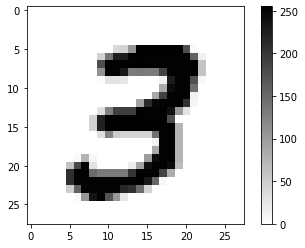

In [24]:
img_array = train_x[7]
x = plt.imshow(img_array, interpolation = "antialiased", alpha = 1, cmap = plt.cm.binary)
plt.colorbar(x)
plt.show()

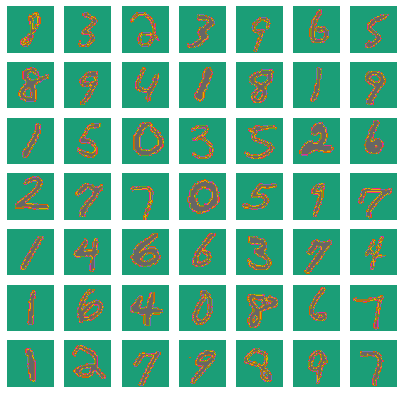

In [25]:
#Here we visualize 49 digits from train dataset

idxs = np.random.randint(0, train_x.shape[0], size = 49)
images = train_x[idxs]
labels = train_y[idxs]

plt.figure(figsize = (7, 7))
for i in range(len(idxs)):
    plt.subplot(7, 7, i + 1)
    image = images[i]
    plt.imshow(image, cmap='Dark2')
    plt.axis('off')
    
plt.show()

#### Here we convert the values of our dataset to "float32" data type. Then we standardize them dividing by 255. Why we divide 255? 

#### Since 255 is the maximum value, dividing by 255 expresses a 0-1 representation. Each channel (Red, Green, and Blue are each channels) is 8 bits, so they are each limited to 256, in this case 255 since 0 is included. As the reference shows, systems typically use values between 0-1 when using floating point values.

In [26]:
train_x = train_x.reshape((60000, 28, 28, 1))
train_x = train_x.astype("float32") / 255

test_x = test_x.reshape((10000, 28, 28, 1))
test_x = test_x.astype("float32") / 255

## One-Hot Encoding
#### What is the meaning of one hot encoding? One hot encoding can be defined as the essential process of converting the categorical data variables to be provided to machine and deep learning algorithms which in turn improve predictions as well as classification accuracy of a model

#### What is the advantage of one hot encoding? One-hot encoding ensures that machine learning does not assume that higher numbers are more important. For example, the value '8' is bigger than the value '1', but that does not make '8' more important than '1'.

### Sample image:

![](http://www.statology.org/wp-content/uploads/2021/09/oneHot1.png)

In [27]:
train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

In [28]:
# we look at encoded train labels
print("Encoded train labels\n", train_y[0:5])
print("\nEncoded test labels\n", test_y[0:5])

Encoded train labels
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

Encoded test labels
 [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


## Building the model


### ● A Sequential model is appropriate for a plain stack of layers where each   layer has exactly one input tensor and one output tensor. A Sequential model is not appropriate when:

####    1. Your model has multiple inputs or multiple outputs
####    2. Any of your layers has multiple inputs or multiple outputs
####    3. You need to do layer sharing
####    4. You want non-linear topology (e.g. a residual connection, a multi-  branch model)

#### Sample image - Sequential layer
![](http://miro.medium.com/max/874/1*eJ36Jpf-DE9q5nKk67xT0Q.jpeg)
_____________________________________________________________________________________________

### ● Conv2D layer creates a convolution kernel that is convolved with the layer input to produce a tensor of outputs. If "use_bias" is True, a bias vector is created and added to the outputs. Finally, if activation is not None, it is applied to the outputs as well.
_____________________________________________________________________________________________

### ● MaxPooling2D class. Max pooling operation for 2D spatial data. Downsamples the input along its spatial dimensions (height and width) by taking the maximum value over an input window (of size defined by pool_size ) for each channel of the input. The window is shifted by strides along each dimension.

#### Sample image - Conv2D and MaxPooling
![](http://media.geeksforgeeks.org/wp-content/uploads/20220306232744/cnn.png)

_____________________________________________________________________________________________

### ● Flatten layer is used to make the multidimensional input one-dimensional, commonly used in the transition from the convolution layer to the full connected layer.

#### Sample image - flattening
![](http://www.researchgate.net/profile/M-Suriya/publication/336320439/figure/fig5/AS:906249382141958@1593078098644/Conversion-of-convoluted-layer-to-flatten-layer.png)

_____________________________________________________________________________________________

### ● Dense Layer is simple layer of neurons in which each neuron receives input from all the neurons of previous layer, thus called as dense. Dense Layer is used to classify image based on output from convolutional layers.

#### Sample image - Dense layer
![image.png](http://epynn.net/_images/Dense-01.svg)

___________________________________________________________________________________

### Why should we use softmax?
#### The softmax function is used as the activation function in the output layer of neural network models that predict a multinomial probability distribution. That is, softmax is used as the activation function for multi-class classification problems where class membership is required on more than two class labels

In [29]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation = "relu", input_shape = (28, 28, 1)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (3, 3), activation = "relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = "relu"))

model.add(layers.Flatten())

model.add(layers.Dense(128, kernel_regularizer = regularizers.l2(0.00001),
                       activation = "relu"))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.1))
model.add(layers.Dense(10, kernel_regularizer = regularizers.l2(0.00001),
                       activation = "softmax"))

## Compiling and Fitting

#### Categorical crossentropy is a loss function that is used in multi-class classification tasks. These are tasks where an example can only belong to one out of many possible categories, and the model must decide which one. Formally, it is designed to quantify the difference between two probability distributions.

____________________________________________________________________________

#### batch_size - is a term that refers to the number of training examples utilized in one iteration
#### epochs - a number of epochs means how many times you go through your training set
____________________________________________________________________________

In [30]:
epoch = 5
batch_size = 64

model.compile(optimizer = "adam",
             loss = "categorical_crossentropy",
             metrics = ["accuracy"])
model.fit(train_x, train_y, epochs = epoch, batch_size = batch_size)

Epoch 1/5
938/938 [==============================] - 5s 4ms/step - loss: 0.1150 - accuracy: 0.9654
Epoch 2/5
938/938 [==============================] - 4s 4ms/step - loss: 0.0442 - accuracy: 0.9871
Epoch 3/5
938/938 [==============================] - 4s 4ms/step - loss: 0.0340 - accuracy: 0.9905
Epoch 4/5
938/938 [==============================] - 4s 4ms/step - loss: 0.0283 - accuracy: 0.9920
Epoch 5/5
938/938 [==============================] - 4s 4ms/step - loss: 0.0228 - accuracy: 0.9939


## Getting model summary

In [31]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
batch_normalization_3 (Batch (None, 26, 26, 32)        128       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 11, 11, 32)        9248      
_________________________________________________________________
batch_normalization_4 (Batch (None, 11, 11, 32)        128       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 5, 5, 32)          0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 3, 3, 64)         

## Model Performance Graph

In [32]:
history = model.fit(train_x, train_y, epochs = epoch, batch_size = batch_size,
                    shuffle = True, validation_split = 0.25)

Epoch 1/5
704/704 [==============================] - 4s 5ms/step - loss: 0.0183 - accuracy: 0.9950 - val_loss: 0.0282 - val_accuracy: 0.9932
Epoch 2/5
704/704 [==============================] - 3s 5ms/step - loss: 0.0172 - accuracy: 0.9956 - val_loss: 0.0288 - val_accuracy: 0.9923
Epoch 3/5
704/704 [==============================] - 3s 5ms/step - loss: 0.0153 - accuracy: 0.9963 - val_loss: 0.0382 - val_accuracy: 0.9900
Epoch 4/5
704/704 [==============================] - 3s 5ms/step - loss: 0.0128 - accuracy: 0.9972 - val_loss: 0.0355 - val_accuracy: 0.9909
Epoch 5/5
704/704 [==============================] - 3s 5ms/step - loss: 0.0158 - accuracy: 0.9959 - val_loss: 0.0326 - val_accuracy: 0.9927


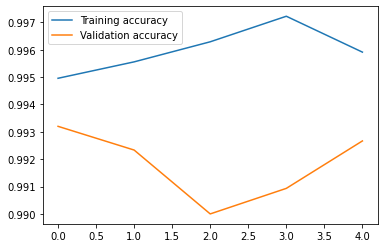

In [33]:
def model_perf(metric, validations_metric):
    plt.plot(history.history[metric], label = str("Training " + metric))
    plt.plot(history.history[validations_metric], label = str("Validation " + metric))
    plt.legend()

model_perf("accuracy", "val_accuracy")

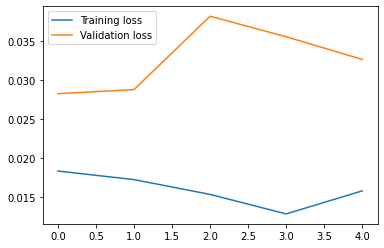

In [34]:
def model_perf(metric, validations_metric):
    plt.plot(history.history[metric], label = str("Training " + metric))
    plt.plot(history.history[validations_metric], label = str("Validation " + metric))
    plt.legend()

model_perf("loss", "val_loss")

### Model evaluate

In [35]:
test_loss, test_acc = model.evaluate(test_x, test_y)
print("Test accuracy: ", test_acc * 100)
print("Test loss: ", test_loss * 100)

313/313 [==============================] - 1s 2ms/step - loss: 0.0335 - accuracy: 0.9920
Test accuracy:  99.19999837875366
Test loss:  3.352636843919754


## New image prediction

In [36]:
'''

def loading_new_image(filename):
    image = load_img(filename, grayscale = True, target_size = (28, 28))
    image = img_to_array(image)
    image = image.reshape(1, 28, 28, 1)
    image = image.astype("float32")
    image = image/255
    return image

def predicting_new_image():
    image = loading_new_image("my_sample_img.jpg")
    predicted = model.predict(image)
    digit = np.argmax(predicted)
    print(digit)
    
predicting_new_image()

'''
pass